# CLIP4CAD-GFA v2 Evaluation

This notebook evaluates the trained GFA v2 model:
1. **Retrieval metrics**: Text→BRep, Text→PC, PC→BRep R@K
2. **Self-grounding quality**: Cosine similarity between guided and self-encoded
3. **Text-free inference**: Compare self-grounding retrieval with text-guided
4. **Ablations**: Test different configurations

## Expected Results
| Metric | GFA v1 | GFA v2 Target |
|--------|--------|---------------|
| Text→BRep R@1 | 54.8% | ≥55% |
| Text→PC R@1 | 59.7% | ≥62% |
| Self cosine | 0.08 | ≥0.90 |

In [14]:
# Cell 1: Imports
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [15]:
# Cell 2: Load Model

from clip4cad.models import CLIP4CAD_GFA_v2, GFAv2Config

# Path to trained model
CHECKPOINT_PATH = Path("../outputs/gfa_v2_4/checkpoint_epoch35.pt")

# Create model with same config
config = GFAv2Config(
    d_face=48,
    d_edge=12,
    d_pc=1024,
    d_text=3072,
    d_unified=256,
    d_proj=128,
    d_ground=128,
    num_slots=12,
    num_detail_queries=8,
)

model = CLIP4CAD_GFA_v2(config).to(device)

# Load weights
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded model from {CHECKPOINT_PATH}")
print(f"Best self-cosine: {checkpoint.get('best_self_cosine', 'N/A')}")

C:\Users\User\AppData\Local\Temp\ipykernel_17840\3294683454.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=device

RuntimeError: Error(s) in loading state_dict for CLIP4CAD_GFA_v2:
	Missing key(s) in state_dict: "grounding.proj_text.weight", "grounding.proj_text.bias", "self_grounding.base_queries", "self_grounding.log_tau", "self_grounding.query_adapter.layers.0.self_attn.in_proj_weight", "self_grounding.query_adapter.layers.0.self_attn.in_proj_bias", "self_grounding.query_adapter.layers.0.self_attn.out_proj.weight", "self_grounding.query_adapter.layers.0.self_attn.out_proj.bias", "self_grounding.query_adapter.layers.0.multihead_attn.in_proj_weight", "self_grounding.query_adapter.layers.0.multihead_attn.in_proj_bias", "self_grounding.query_adapter.layers.0.multihead_attn.out_proj.weight", "self_grounding.query_adapter.layers.0.multihead_attn.out_proj.bias", "self_grounding.query_adapter.layers.0.linear1.weight", "self_grounding.query_adapter.layers.0.linear1.bias", "self_grounding.query_adapter.layers.0.linear2.weight", "self_grounding.query_adapter.layers.0.linear2.bias", "self_grounding.query_ad

In [5]:
# Cell 3: Load Data using GFAMappedDataset (same as train_gfa.ipynb)

from clip4cad.data.gfa_dataset import GFAMappedDataset

DATA_ROOT = Path("d:/Defect_Det/MMCAD/data")
PC_FILE = Path("c:/Users/User/Desktop/pc_embeddings_full.h5")
BREP_FILE = Path("c:/Users/User/Desktop/brep_features.h5")
TEXT_FILE = Path("c:/Users/User/Desktop/text_embeddings.h5")

print("Loading validation dataset...")

val_dataset = GFAMappedDataset(
    data_root=str(DATA_ROOT),
    split="val",
    pc_file=str(PC_FILE),
    text_file=str(TEXT_FILE),
    brep_file=str(BREP_FILE),
    num_rotations=1,
    load_to_memory=False,  # Keep on disk to save RAM
    use_live_text=False,
)

print(f"Validation samples: {len(val_dataset)}")

Loading validation dataset...
GFAMappedDataset: val with 16638 samples
Validation samples: 16638


In [6]:
# Cell 4: Encode All Samples

from clip4cad.data.gfa_dataset import gfa_collate_fn

@torch.no_grad()
def encode_all_samples(model, dataset, use_self_grounding=False):
    """Encode all samples and return embeddings."""
    model.eval()
    
    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        collate_fn=gfa_collate_fn,
    )
    
    z_brep_all = []
    z_pc_all = []
    z_text_all = []
    
    for batch in tqdm(loader, desc="Encoding"):
        outputs = model(batch)
        
        # Get embeddings (guided or self)
        if use_self_grounding:
            z_brep = F.normalize(outputs['z_brep_self'], dim=-1)
            z_pc = F.normalize(outputs['z_pc_self'], dim=-1)
        else:
            z_brep = F.normalize(outputs['z_brep'], dim=-1)
            z_pc = F.normalize(outputs['z_pc'], dim=-1)
        
        z_text = F.normalize(outputs['z_text'], dim=-1)
        
        z_brep_all.append(z_brep.cpu())
        z_pc_all.append(z_pc.cpu())
        z_text_all.append(z_text.cpu())
    
    return (
        torch.cat(z_brep_all),
        torch.cat(z_pc_all),
        torch.cat(z_text_all)
    )

# Encode with text-guided
print("Encoding with text-guided...")
z_brep_guided, z_pc_guided, z_text = encode_all_samples(model, val_dataset, use_self_grounding=False)

# Encode with self-grounding
print("Encoding with self-grounding...")
z_brep_self, z_pc_self, _ = encode_all_samples(model, val_dataset, use_self_grounding=True)

print(f"\nEmbedding shapes:")
print(f"  z_brep_guided: {z_brep_guided.shape}")
print(f"  z_brep_self: {z_brep_self.shape}")
print(f"  z_pc_guided: {z_pc_guided.shape}")
print(f"  z_text: {z_text.shape}")

Encoding with text-guided...


Encoding:   0%|          | 0/260 [00:00<?, ?it/s]

Encoding with self-grounding...


Encoding:   0%|          | 0/260 [00:00<?, ?it/s]


Embedding shapes:
  z_brep_guided: torch.Size([16638, 128])
  z_brep_self: torch.Size([16638, 128])
  z_pc_guided: torch.Size([16638, 128])
  z_text: torch.Size([16638, 128])


In [7]:
# Cell 5: Compute Retrieval Metrics

def compute_retrieval_metrics(query_emb, gallery_emb, k_values=[1, 5, 10]):
    """Compute R@K retrieval metrics."""
    # Compute similarity matrix
    sim = query_emb @ gallery_emb.T  # (N, N)
    
    # Get rankings
    rankings = torch.argsort(sim, dim=1, descending=True)
    
    # Ground truth: diagonal is correct
    N = query_emb.shape[0]
    labels = torch.arange(N)
    
    results = {}
    for k in k_values:
        top_k = rankings[:, :k]
        correct = (top_k == labels.unsqueeze(1)).any(dim=1)
        results[f'R@{k}'] = correct.float().mean().item() * 100
    
    # Mean Reciprocal Rank
    ranks = (rankings == labels.unsqueeze(1)).nonzero()[:, 1] + 1
    results['MRR'] = (1.0 / ranks.float()).mean().item() * 100
    
    return results

print("="*70)
print("RETRIEVAL RESULTS (Text-Guided)")
print("="*70)

# Text → BRep
text_brep_results = compute_retrieval_metrics(z_text, z_brep_guided)
print(f"\nText → BRep:")
for k, v in text_brep_results.items():
    print(f"  {k}: {v:.2f}%")

# Text → PC
text_pc_results = compute_retrieval_metrics(z_text, z_pc_guided)
print(f"\nText → PC:")
for k, v in text_pc_results.items():
    print(f"  {k}: {v:.2f}%")

# PC → BRep
pc_brep_results = compute_retrieval_metrics(z_pc_guided, z_brep_guided)
print(f"\nPC → BRep:")
for k, v in pc_brep_results.items():
    print(f"  {k}: {v:.2f}%")

RETRIEVAL RESULTS (Text-Guided)

Text → BRep:
  R@1: 67.72%
  R@5: 90.03%
  R@10: 94.16%
  MRR: 77.62%

Text → PC:
  R@1: 89.66%
  R@5: 98.24%
  R@10: 99.09%
  MRR: 93.58%

PC → BRep:
  R@1: 65.43%
  R@5: 89.25%
  R@10: 93.81%
  MRR: 75.95%


In [8]:
# Cell 6: Self-Grounding Quality

print("="*70)
print("SELF-GROUNDING QUALITY")
print("="*70)

# Cosine similarity between guided and self
cos_brep = (z_brep_guided * z_brep_self).sum(dim=-1).mean().item()
cos_pc = (z_pc_guided * z_pc_self).sum(dim=-1).mean().item()

print(f"\nBRep Guided-Self Cosine: {cos_brep:.4f}")
print(f"PC Guided-Self Cosine: {cos_pc:.4f}")

if cos_brep > 0.9:
    print("\n✓ Self-grounding quality is EXCELLENT (target: > 0.9)")
elif cos_brep > 0.8:
    print("\n○ Self-grounding quality is GOOD (target: > 0.9)")
else:
    print(f"\n✗ Self-grounding quality needs improvement (target: > 0.9)")

SELF-GROUNDING QUALITY

BRep Guided-Self Cosine: 0.1472
PC Guided-Self Cosine: 0.3375

✗ Self-grounding quality needs improvement (target: > 0.9)


In [9]:
# Cell 7: Text-Free Inference (Self-Grounding Retrieval)

print("="*70)
print("TEXT-FREE INFERENCE (Self-Grounding)")
print("="*70)

# Text → BRep with self-grounding
text_brep_self_results = compute_retrieval_metrics(z_text, z_brep_self)
print(f"\nText → BRep (Self-Grounding):")
for k, v in text_brep_self_results.items():
    print(f"  {k}: {v:.2f}%")

# Compare with guided
r1_diff = text_brep_self_results['R@1'] - text_brep_results['R@1']
print(f"\nDifference from text-guided: {r1_diff:+.2f}%")

if abs(r1_diff) < 5:
    print("\n✓ Self-grounding achieves similar performance to text-guided!")
else:
    print("\n○ Self-grounding is still learning...")

TEXT-FREE INFERENCE (Self-Grounding)

Text → BRep (Self-Grounding):
  R@1: 0.05%
  R@5: 0.29%
  R@10: 0.61%
  MRR: 0.41%

Difference from text-guided: -67.67%

○ Self-grounding is still learning...


In [10]:
# Cell 8: Summary Table

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print(f"\n{'Metric':<30} {'Value':<15} {'Target':<15} {'Status'}")
print("-" * 70)

metrics = [
    ('Text→BRep R@1 (guided)', f"{text_brep_results['R@1']:.2f}%", '≥55%', text_brep_results['R@1'] >= 55),
    ('Text→PC R@1 (guided)', f"{text_pc_results['R@1']:.2f}%", '≥62%', text_pc_results['R@1'] >= 62),
    ('PC→BRep R@1', f"{pc_brep_results['R@1']:.2f}%", '≥32%', pc_brep_results['R@1'] >= 32),
    ('Self-grounding cosine', f"{cos_brep:.4f}", '≥0.90', cos_brep >= 0.9),
    ('Text→BRep R@1 (self)', f"{text_brep_self_results['R@1']:.2f}%", 'Within 5%', abs(r1_diff) < 5),
]

for metric, value, target, passed in metrics:
    status = '✓' if passed else '✗'
    print(f"{metric:<30} {value:<15} {target:<15} {status}")

passed_count = sum(1 for _, _, _, p in metrics if p)
print(f"\nPassed: {passed_count}/{len(metrics)}")


SUMMARY

Metric                         Value           Target          Status
----------------------------------------------------------------------
Text→BRep R@1 (guided)         67.72%          ≥55%            ✓
Text→PC R@1 (guided)           89.66%          ≥62%            ✓
PC→BRep R@1                    65.43%          ≥32%            ✓
Self-grounding cosine          0.1472          ≥0.90           ✗
Text→BRep R@1 (self)           0.05%           Within 5%       ✗

Passed: 3/5


c:\Users\User\anaconda3\envs\clip4cad\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


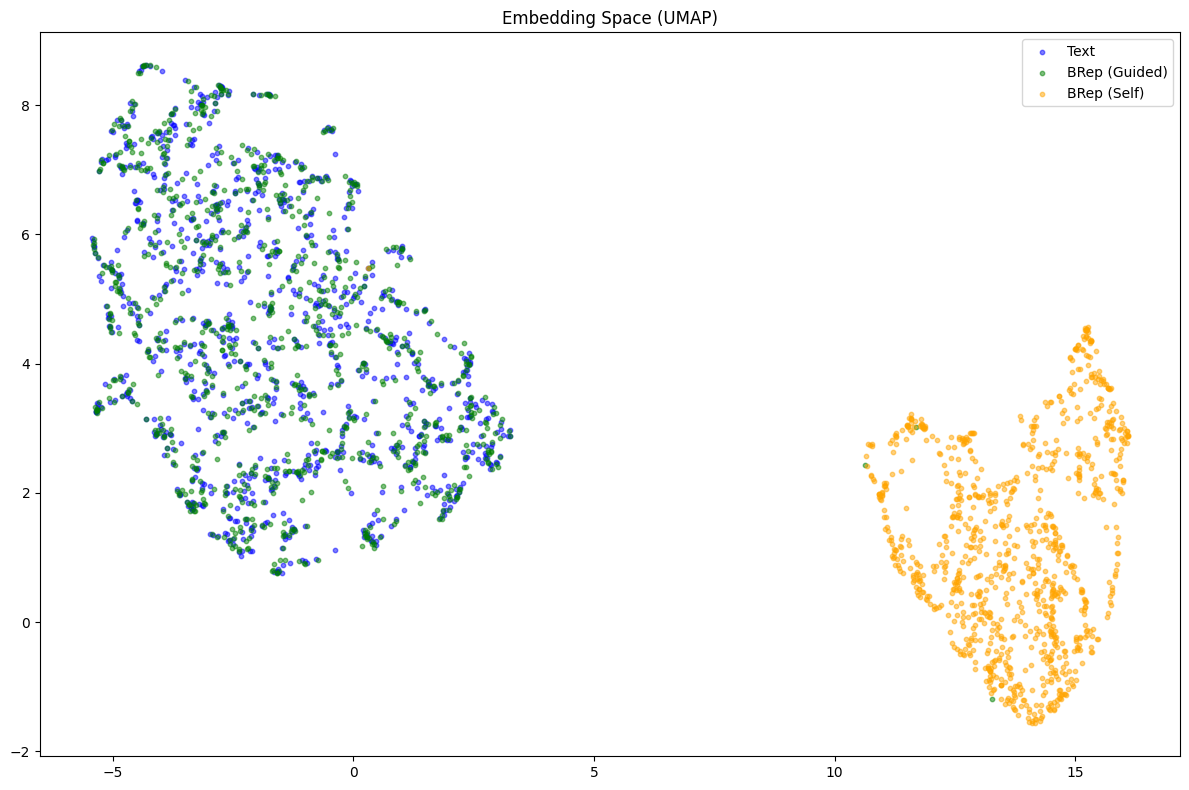

In [12]:
# Cell 9: Embedding Visualization (Optional)

# Use UMAP or t-SNE to visualize embeddings
try:
    from umap import UMAP
    
    # Sample for visualization
    sample_size = min(1000, len(z_text))
    idx = np.random.choice(len(z_text), sample_size, replace=False)
    
    # Combine embeddings
    all_emb = np.vstack([
        z_text[idx].numpy(),
        z_brep_guided[idx].numpy(),
        z_brep_self[idx].numpy(),
    ])
    
    labels = np.array(
        ['Text'] * sample_size + 
        ['BRep (Guided)'] * sample_size + 
        ['BRep (Self)'] * sample_size
    )
    
    # Reduce dimensions
    reducer = UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    emb_2d = reducer.fit_transform(all_emb)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = {'Text': 'blue', 'BRep (Guided)': 'green', 'BRep (Self)': 'orange'}
    for label in ['Text', 'BRep (Guided)', 'BRep (Self)']:
        mask = labels == label
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
                   c=colors[label], label=label, alpha=0.5, s=10)
    
    ax.legend()
    ax.set_title('Embedding Space (UMAP)')
    plt.tight_layout()
    plt.savefig('../outputs/gfa_v2/embedding_visualization.png', dpi=150)
    plt.show()
    
except ImportError:
    print("UMAP not installed. Run: pip install umap-learn")

## Ablation Studies

Use the cells below to test different ablation configurations.

In [13]:
# Cell 10: Ablation - No Self Contrastive (lambda_self=0)

# Load ablation model if available
ABLATION_PATH = Path("../outputs/gfa_v2_ablation_no_self/checkpoint_best.pt")

if ABLATION_PATH.exists():
    ablation_model = CLIP4CAD_GFA_v2(config).to(device)
    ablation_checkpoint = torch.load(ABLATION_PATH, map_location=device)
    ablation_model.load_state_dict(ablation_checkpoint['model_state_dict'])
    ablation_model.eval()
    
    print("Ablation A1: No Self Contrastive (lambda_self=0)")
    print("="*50)
    
    z_brep_abl, z_pc_abl, z_text_abl = encode_all_samples(ablation_model, val_common_uids)
    z_brep_self_abl, _, _ = encode_all_samples(ablation_model, val_common_uids, use_self_grounding=True)
    
    # Retrieval
    abl_results = compute_retrieval_metrics(z_text_abl, z_brep_abl)
    print(f"Text → BRep R@1: {abl_results['R@1']:.2f}%")
    
    # Self-grounding quality
    cos_abl = (z_brep_abl * z_brep_self_abl).sum(dim=-1).mean().item()
    print(f"Self-grounding cosine: {cos_abl:.4f}")
    
    if cos_abl < 0.5:
        print("\n✓ Confirmed: Self contrastive is ESSENTIAL for self-grounding!")
else:
    print(f"Ablation checkpoint not found: {ABLATION_PATH}")
    print("To run this ablation, train with lambda_self=0")

Ablation checkpoint not found: ..\outputs\gfa_v2_ablation_no_self\checkpoint_best.pt
To run this ablation, train with lambda_self=0
